# WP4v5 — Pair Generation & Training

## Part 1 — Pair Generation

**Strategy**: for each image, generate 100 masked MAE CLS representations (seeds 0..99),
then create K=50 representations by averaging 5 random draws from the 100.

**Optimized storage**:
- `mae_avg`: (N×50, 1024) — averaged MAE representations, raw
- `img_idx`: (N×50,) — source image index (to retrieve the CLIP CLS)
- `cls_clip`: (N, 1024) — **once per image** (not 50 times)
- `labels`: (N,)

Total: ~27 GB instead of ~53 GB if cls_clip were repeated 50 times.

In [ ]:
import torch
import torch.nn.functional as F
from transformers import ViTImageProcessor, ViTMAEModel
from transformers import LlavaForConditionalGeneration, CLIPImageProcessor
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import numpy as np

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
N_MASKS     = 50  # tirages masques par image
K_GROUPS    = 50   # groupes moyennes par image
GROUP_SIZE  = 5    # taille de chaque groupe

print(f'Device : {DEVICE}')
print(f'Paires generees par image : {K_GROUPS} (moyenne de {GROUP_SIZE} parmi {N_MASKS} masquages)')


/home/philippelin/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
Paires generees par image : 50 (moyenne de 5 parmi 100 masquages)


In [ ]:
import os
MAE_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'
LLAVA_PATH = './llava-1.5-7b-hf' if os.path.exists('./llava-1.5-7b-hf') else 'llava-hf/llava-1.5-7b-hf'

mae_processor = ViTImageProcessor(
    size={'height': 224, 'width': 224},
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
)
mae_encoder = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE)
mae_encoder.eval()

llava = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_PATH, torch_dtype=torch.float16
)
vision_tower = llava.vision_tower.to(DEVICE).eval()
del llava; torch.cuda.empty_cache()
clip_proc = CLIPImageProcessor.from_pretrained(LLAVA_PATH)
print(f'Modeles charges — VRAM : {torch.cuda.memory_allocated()/1e9:.1f} GB')


In [ ]:
# Auto-download ImageNet-100 if not found locally
DATASET_DIR = './imagenet100-hf' if os.path.exists('./imagenet100-hf/data') else './imagenet100'
if not os.path.exists(f'{DATASET_DIR}/data'):
    from huggingface_hub import snapshot_download
    DATASET_DIR = './imagenet100-hf'
    print('Downloading ImageNet-100 (~17 GB)...')
    snapshot_download(repo_id='ilee0022/ImageNet100', repo_type='dataset', local_dir=DATASET_DIR)
    print('Done.')
ds_train = load_dataset('parquet', data_files={'train': f'{DATASET_DIR}/data/train-*.parquet'})
ds_val   = load_dataset('parquet', data_files={'validation': f'{DATASET_DIR}/data/validation-*.parquet'})

transform = transforms.Compose([
    transforms.Resize(384), transforms.CenterCrop(336), transforms.ToTensor(),
])

class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset; self.transform = transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        img  = item['image'].convert('RGB')
        if self.transform: img = self.transform(img)
        return img, item['label']

dataset_train = HFImageDataset(ds_train['train'],    transform=transform)
dataset_val   = HFImageDataset(ds_val['validation'], transform=transform)
print(f'Train : {len(dataset_train)} images -> {len(dataset_train)*K_GROUPS} paires')
print(f'Val   : {len(dataset_val)} images -> {len(dataset_val)*K_GROUPS} paires')


In [ ]:
def generate_pairs(dataset, batch_size=32, desc=''):
    """
    Pour chaque image :
    1. Calculer CLS CLIP une fois
    2. Calculer N_MASKS=100 CLS MAE masques
    3. Creer K_GROUPS=50 representations en moyennant GROUP_SIZE=5 masquages aleatoires

    Retourne (BRUT, non normalise) :
    - mae_avg  : (N*K, 1024) — representations moyennees
    - cls_clip : (N, 1024)   — une par image, L2-normalise
    - img_idx  : (N*K,)      — index de l'image source
    - labels   : (N,)
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=(DEVICE=='cuda'))

    all_mae_avg  = []
    all_cls_clip = []
    all_img_idx  = []
    all_labels   = []
    global_idx   = 0

    for images_336, labels in tqdm(loader, desc=desc):
        B = images_336.shape[0]
        images_224 = F.interpolate(images_336, size=(224,224),
                                   mode='bilinear', align_corners=False)

        # --- CLS CLIP (une seule fois par image) ---
        clip_in = clip_proc(images=list(images_336), return_tensors='pt', do_rescale=False)
        pix = clip_in['pixel_values'].to(DEVICE).half()
        with torch.no_grad():
            cls_clip_batch = vision_tower(pix).last_hidden_state[:, 0]  # (B, 1024)
        cls_clip_batch = F.normalize(cls_clip_batch.cpu().float(), dim=-1)

        # --- N_MASKS CLS MAE masques par image ---
        mae_in = mae_processor(images=list(images_224), return_tensors='pt', do_rescale=False)
        mae_in = {k: v.to(DEVICE) for k, v in mae_in.items()}

        cls_pool = []  # (N_MASKS, B, 1024)
        for seed in range(N_MASKS):
            gen   = torch.Generator().manual_seed(seed)
            noise = torch.rand(B, 196, generator=gen).to(DEVICE)
            with torch.no_grad():
                out = mae_encoder(**mae_in, noise=noise)
            cls_pool.append(out.last_hidden_state[:, 0].cpu().float())  # (B, 1024)

        cls_pool = torch.stack(cls_pool)  # (N_MASKS, B, 1024)

        # --- K_GROUPS moyennes aleatoires de GROUP_SIZE masquages ---
        mae_avg_batch = []  # (K_GROUPS, B, 1024)
        for _ in range(K_GROUPS):
            # Choisir GROUP_SIZE seeds aleatoirement parmi N_MASKS
            chosen = torch.randperm(N_MASKS)[:GROUP_SIZE]
            avg    = cls_pool[chosen].mean(dim=0)  # (B, 1024)
            mae_avg_batch.append(avg)

        # Restructurer : (K_GROUPS*B, 1024)
        mae_avg_batch = torch.cat(mae_avg_batch, dim=0)  # (K_GROUPS*B, 1024)

        # img_idx : pour chaque paire, quel est l'index de l'image source
        img_idx = torch.arange(global_idx, global_idx + B).repeat(K_GROUPS)  # (K_GROUPS*B,)

        all_mae_avg.append(mae_avg_batch)
        all_cls_clip.append(cls_clip_batch)   # (B, 1024) — une par image
        all_img_idx.append(img_idx)
        all_labels.append(labels)
        global_idx += B

    return {
        'mae_avg':  torch.cat(all_mae_avg),   # (N*K, 1024)
        'cls_clip': torch.cat(all_cls_clip),  # (N, 1024)
        'img_idx':  torch.cat(all_img_idx),   # (N*K,)
        'labels':   torch.cat(all_labels),    # (N,)
    }

data_train = generate_pairs(dataset_train, batch_size=32, desc='Train')
data_val   = generate_pairs(dataset_val,   batch_size=32, desc='Val')

torch.save(data_train, 'wp4v5_pairs_train.pt')
torch.save(data_val,   'wp4v5_pairs_val.pt')
print('Sauvegarde OK')
print(f'  mae_avg  : {data_train["mae_avg"].shape}')   # (N*K, 1024)
print(f'  cls_clip : {data_train["cls_clip"].shape}')  # (N, 1024)
print(f'  img_idx  : {data_train["img_idx"].shape}')   # (N*K,)


In [ ]:
# Stats de normalisation sur mae_avg du train
norm_mean = data_train['mae_avg'].mean(dim=0)
norm_std  = data_train['mae_avg'].std(dim=0).clamp(min=1e-6)
torch.save({'mean': norm_mean, 'std': norm_std}, 'wp4v5_norm_stats.pt')
print('Stats sauvegardees')

# Verification discriminabilite inter-images
idx5 = [i * K_GROUPS for i in range(5)]
vecs = F.normalize(data_val['mae_avg'][idx5], dim=-1)
sim  = (vecs @ vecs.T).numpy()
print('\nSimilarites cosinus mae_avg inter-images (groupe 0) :')
print(sim.round(4))

# Verification intra-image (5 groupes de la meme image)
vecs2 = F.normalize(data_val['mae_avg'][:5], dim=-1)  # 5 groupes image 0
sim2  = (vecs2 @ vecs2.T).numpy()
print('\nSimilarites cosinus mae_avg intra-image (5 groupes, image 0) :')
print(sim2.round(4))

del vision_tower, mae_encoder; torch.cuda.empty_cache()


---
## Part 2 — Training

Cosine loss on pairs `(mae_avg_normalized, cls_clip)`.
6.5M pairs (130k images × 50 groups of 5 masks from 100).

The enriched dataset provides input diversity — the cosine loss
ensures geometric fusion of the two spaces (absolute proximity).

In [2]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')


Device : cuda


## 2.1 Loading and normalization

In [3]:
data_train = torch.load('wp4v5_pairs_train.pt')
data_val   = torch.load('wp4v5_pairs_val.pt')

norm = torch.load('wp4v5_norm_stats.pt')
norm_mean = norm['mean']
norm_std  = norm['std']

# Normaliser mae_avg avec stats train
mae_train = (data_train['mae_avg'] - norm_mean) / norm_std
mae_val   = (data_val['mae_avg']   - norm_mean) / norm_std

# cls_clip indexe par img_idx (une representation par image)
# On construit un dataset qui retourne (mae_avg_normalise, cls_clip_cible)
# en utilisant img_idx pour retrouver le bon cls_clip
clip_train = data_train['cls_clip'][data_train['img_idx'] % len(data_train['cls_clip'])]  # (N*K, 1024)
clip_val   = data_val['cls_clip'][data_val['img_idx'] % len(data_val['cls_clip'])]

print(f'Train : {len(mae_train)} paires | Val : {len(mae_val)} paires')
print(f'mae_train — mean: {mae_train.mean():.4f}, std: {mae_train.std():.4f}')

BATCH_SIZE   = 8192
train_loader = DataLoader(TensorDataset(mae_train, clip_train),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(mae_val,   clip_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Train : 5850000 paires | Val : 650000 paires
mae_train — mean: -0.0000, std: 1.0000


## 2.2 MLP Architecture

In [4]:
class ResidualBlock(nn.Module):
    """Bloc résiduel pré-norm : LayerNorm -> Linear -> GELU -> Dropout -> Linear + skip."""
    def __init__(self, dim=1024, dropout=0.3):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.lin1  = nn.Linear(dim, dim)
        self.act   = nn.GELU()
        self.drop  = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.lin2  = nn.Linear(dim, dim)

    def forward(self, x):
        h = self.lin1(self.norm1(x))
        h = self.drop(self.act(h))
        h = self.lin2(self.norm2(h))
        return x + h  # skip connection


class ProjectionMLP(nn.Module):
    def __init__(self, dim=1024, n_blocks=6, dropout=0.3):
        super().__init__()
        self.blocks = nn.ModuleList([
            ResidualBlock(dim, dropout) for _ in range(n_blocks)
        ])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return F.normalize(x, dim=-1)


f_theta = ProjectionMLP().to(DEVICE)
print(f'Parametres      : {sum(p.numel() for p in f_theta.parameters()):,}')

Parametres      : 12,619,776


## 2.3 Training

In [ ]:
N_EPOCHS     = 200
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 20

optimizer = AdamW(f_theta.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)
history   = {'train_loss': [], 'val_loss': [], 'val_cos': [], 'val_euc': []}
best_euc, best_epoch, patience_counter = float('inf'), 0, 0

def cosine_loss(a, b): return (1 - F.cosine_similarity(a, b)).mean()

def eval_epoch(loader):
    f_theta.eval()
    tl, tc, te, n = 0., 0., 0., 0
    with torch.no_grad():
        for z, c in loader:
            z, c = z.to(DEVICE), c.to(DEVICE)
            p = f_theta(z)
            tl += cosine_loss(p, c).item() * z.shape[0]
            tc += F.cosine_similarity(p, c).mean().item() * z.shape[0]
            te += torch.norm(p - c, dim=-1).mean().item() * z.shape[0]
            n  += z.shape[0]
    return tl/n, tc/n, te/n

for epoch in range(N_EPOCHS):
    f_theta.train()
    tl, n = 0., 0
    for z, c in train_loader:
        z, c = z.to(DEVICE), c.to(DEVICE)
        optimizer.zero_grad()
        loss = cosine_loss(f_theta(z), c)
        loss.backward()
        optimizer.step()
        tl += loss.item() * z.shape[0]; n += z.shape[0]

    train_loss = tl/n
    val_loss, val_cos, val_euc = eval_epoch(val_loader)
    scheduler.step(val_euc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos'].append(val_cos)
    history['val_euc'].append(val_euc)

    if val_euc < best_euc:
        best_euc, best_epoch, patience_counter = val_euc, epoch+1, 0
        torch.save(f_theta.state_dict(), 'wp4v5_ftheta_best.pt')
    else:
        patience_counter += 1

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d} | train={train_loss:.4f} | val_cos_loss={val_loss:.4f} | '
              f'cos={val_cos:.4f} | euc={val_euc:.4f} | patience={patience_counter}/{PATIENCE}')
    if patience_counter >= PATIENCE:
        print(f'Early stopping a l epoch {epoch+1}'); break

print(f'Meilleur modele : epoch {best_epoch}, val_euc={best_euc:.4f}')

Epoch   5 | train=0.0913 | val_cos_loss=0.0935 | cos=0.9065 | euc=0.4186 | patience=0/20
Epoch  10 | train=0.0789 | val_cos_loss=0.0915 | cos=0.9085 | euc=0.4132 | patience=0/20
Epoch  15 | train=0.0741 | val_cos_loss=0.0914 | cos=0.9086 | euc=0.4128 | patience=1/20


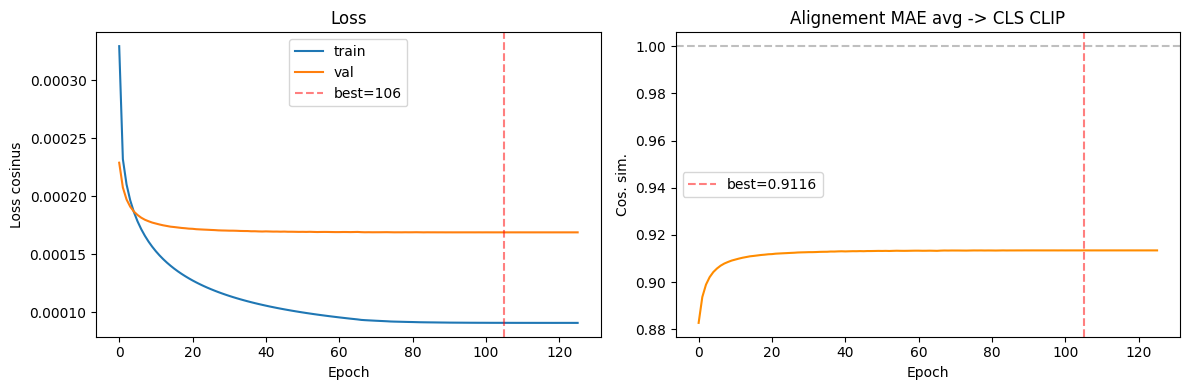

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'best={best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss cosinus')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_cos'], color='darkorange')
axes[1].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cos. sim.')
axes[1].set_title('Alignement MAE avg -> CLS CLIP'); axes[1].legend()
plt.tight_layout()
plt.savefig('wp4v5_training_curves.png', dpi=150)
plt.show()
